# Logistic Perceptron

In diesem Kapitel behandeln wir das Logistische Perzeptron und dessen Herleitung. Dieses Kapitel ist fundamental zur Verständnisbildung für Deep Learning in zweierlei Hinsicht:

1. Es findet nun eine transition von regelbasierten Lernverfahren, wie der Fehlerzähler aus dem Kapitel Perzeptron zu Optimierungsbasierten Modellen statt. 

2. Es wird aufgezeigt das die Modellausgabe und das Optimierungsziel aufeinander abgestimmt werden müssen.  

3. Interpretation der Ausgabe

Objectives: 

Das logistische Perzeptron verstehen

Zusammenhang zwischen Liklihood und BCE beim logistischen Perzeptron aus der Herleitung binomialverteilten 
generalisierten linearen Modellen

Sigmoid für Binary Classification, Softmax für ...

Vorwissen:
- Perzeptron
- Gradient Descent


As discussed in the previous chapter, the Rosenblatt perceptron produces strictly binary outputs and is not trained by minimising a continuous objective function.
The logistic perceptron addresses both limitations by replacing the hard threshold with a smooth activation function. To motivate this change, we first consider a small synthetic binary classification dataset.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import beginner.perceptron.perceptron as perceptron

In [2]:
rng = np.random.default_rng(53)


## Widerholung Aktivierung

Da sich das Modell nur in der Verwendung der Sigmoid als Aktivierungsfunktion in der Ausgabe unterscheidet,
schauen wir uns das als Auffrischung nochmal an. 


**Sigmoid:**
$$ f(x)=\frac{1}{1+e^{-x}} $$

You can see at a glance that:
- The value range is in **(0,1)**
- Monotonically increasing
- For large **|x|**, the value approaches **0** or **1**
- Continuously differentiable

The output of the sigmoid function can be given semantics. For binary classification, this means:
- $\sigma(z) < 0.5$ → Class **0**
- $\sigma(z) >= 0.5$ → Class **1**


**Step function:**

You can see at a glance:
- Values can only be **0** or **1**
- **x = 0** is not defined
- even if differentiable, slope = 0 -> no usable gradient -> no information content


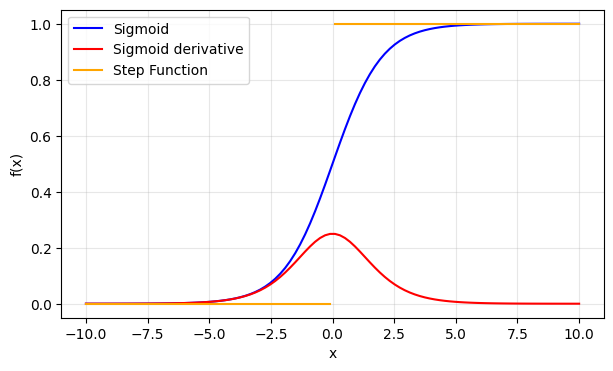

In [3]:
x = np.linspace(-10, 10, 100)
fig2, ax2 = plt.subplots(figsize=(7, 4))

ax2.plot(x, perceptron.sigmoid(x), c="blue", label="Sigmoid")
ax2.plot(x, perceptron.sigmoid_derivative(x), c="red", label="Sigmoid derivative")
ax2.plot(x[x < 0], perceptron.step_function(x[x < 0]), c="orange", label="Step Function")
ax2.plot(x[x >= 0], perceptron.step_function(x[x >= 0]), c="orange")

ax2.grid(alpha=0.3)
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.legend();

## Data generation
Zuerest wird ein linear separables synthetisches Dataset mit einer fiktiven Entscheidungsgrenze erzeugt. Datenpunkte unterhalb dieser Grenze werden Klasse 0 zugeordnet, Datenpunkte oberhalb Klasse 1.


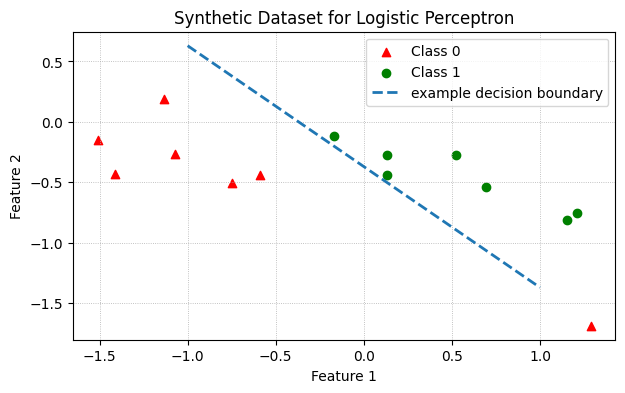

In [4]:
X, y = make_classification(
    n_samples=14,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.5,
    flip_y=0.0,
    random_state=53
)
y_train = np.asarray(y).reshape(-1, 1)

def visualize_data(X: np.ndarray, y:np.ndarray, title:str):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(X[y==0,0], X[y==0,1], color="red", marker="^", label="Class 0")
    ax.scatter(X[y==1,0], X[y==1,1], color="green", marker="o", label="Class 1")    
    ax.legend()
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.grid(ls=":", linewidth=0.6)
    return fig, ax

fig1,ax1 = visualize_data(X,y,"Synthetic Dataset for Logistic Perceptron")
perceptron.ex_boundary_helper(ax1,-0.37)

Nun trainineren wir das logistische Perzeptron mit dem Fehlerzähler aus dem Kapitel Perceptron und betrachten die Ausgabe für jeden Datenpunkt.

Dev Diary:
Obwohl unsere train methode ein y mit shape (n_samples, 1) erwartet, habe ich ein shape von (14,) übergeben.
Da war mein Kopf auf Durchzug geschaltet, obwohl ich mir beidem bewusst war. Nervige Bugssuche... 


Solution in Epoch 48


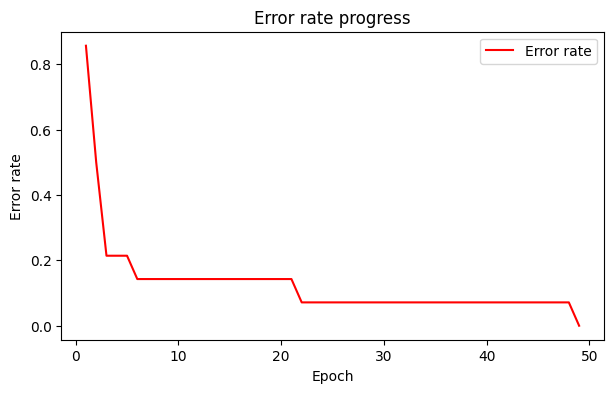

In [5]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
error_history,_ = model.train(X, y_train, lr=0.1, error_prints=False, epochs=100)
fig2, ax2 = perceptron.visualize_training(error_history)



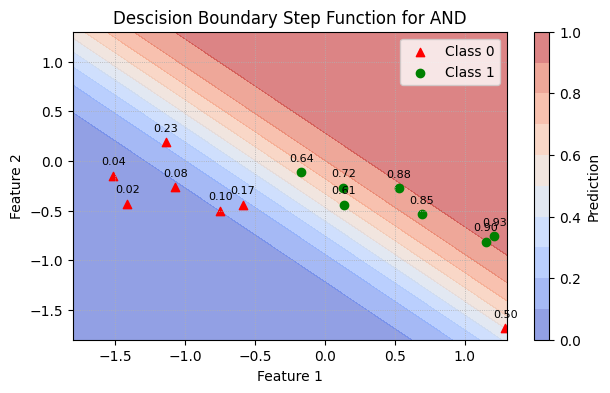

In [6]:
n = 1000
x1 = np.linspace(-1.8, 1.3, n)
x2 = np.linspace(-1.8, 1.3, n)
x1_grid, x2_grid = np.meshgrid(x1, x2)
X_viz = np.c_[x1_grid.flatten(), x2_grid.flatten()]
assert X_viz.shape == (n*n, 2), (
    "Shape Mismatch for forward pass -> expect shape (samplesize,2)"
    )

y_viz = model.forward(X_viz).reshape(n,-1)
fig2, ax2 = visualize_data(X,y,"Descision Boundary Step Function for AND")
cf = ax2.contourf(x1_grid, x2_grid, y_viz, levels=10, cmap='coolwarm', alpha=0.6, zorder=0)

y_forward = model.forward(X).ravel()
for xi, y_hat in zip(X, y_forward):
    ax2.annotate(
        f"{y_hat:.2f}", 
        xy=(xi[0], xi[1]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
fig2.colorbar(cf, label="Prediction");

## Auswertung Sigmoid mit Fehlerzähler
Der Ausgabewert kann somit zunächst als geometrisch interpretierbarer Entscheidungsscore relativ zur Entscheidungsgrenze aufgefasst werden. Hohe Werte entsprechen Punkten auf der Seite von Klasse 1, niedrige Werte Punkten auf der Seite von Klasse 0. Je näher ein Datenpunkt an der Entscheidungsgrenze liegt, desto näher liegt die Ausgabe bei 0,5.

 Im ersten Teil des Kapitels betrachten wir also wie wir durch die Änderung des regelbasierten lernens zu einem Optimierungsziel es hinbekommen den score in eine Wahrscheinlichkeit umzuwandeln. Dieses Verständnis ist grundlegend, weil die Bedeutung einer Modellausgabe nicht allein durch ihren Zahlenwert entsteht, sondern durch das Zusammenspiel aus Ausgabefunktion und Optimierungsziel. Ein Wert zwischen 0 und 1 ist daher nicht automatisch eine Wahrscheinlichkeit. Erst wenn die Ausgabe mathematisch zum gewählten Lernziel passt, lässt sie sich sinnvoll interpretieren. Dadurch wird deutlich, warum Modelle nicht nur danach betrachtet werden können, welche Werte sie ausgeben, sondern auch danach, mit welchem Ziel diese Werte gelernt werden. Der Übergang vom regelbasierten Fehlerzählen zur Optimierung der Binary Cross Entropy zeigt genau diesen Unterschied: Aus einem bloßen Entscheidungsscore wird eine probabilistisch begründete Vorhersage.

## Nonlinear seperable Synthetic Dataset

Für die folgenden Abschnitte verwenden wir nun ein nicht linear seperables Dataset mit zwei Merkmalen und binären Zielwerten. Wie im Kapitel Perzeptron bereits anschaulich gezeigt, kommen wir damit an die Grenzen des Fehlerzählers als regelbasiertes Lernverfahren....? Überprüfen ggf ändern
Der Fehlerzähler unterscheidet nur zwischen richtig und falsch. Eine Vorhersage von $p=0{,}51$ und eine von $p=0{,}99$ werden bei wahrem Label $y=1$ beide als korrekt gezählt.

Wir verwenden ein synthetisches Dataset als beobachtete Stichprobe. Das Modell sieht nur diese Datenpunkte und soll aus ihnen eine Beziehung zwischen Merkmalen und binären Labels lernen.

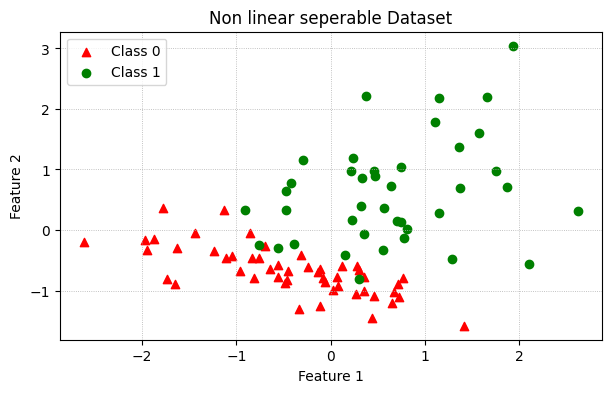

In [7]:
X, y = make_classification(
    n_samples=90,
    n_features=2,
    n_redundant=0,
    weights=[0.55, 0.45],
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.6,
    flip_y=0.0,
    random_state=51
)
fig3,ax3 = visualize_data(X,y,"Non linear seperable Dataset")

Eine schnelle Exploration zeigt, dass eine Klasseninbalanz herrscht. Klasse 1 kommt im Dataset seltener vor.

In [8]:
unique, counts = np.unique(y, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Absolute frequency": counts,
    "Relative frequency": (counts / len(y)).round(2)
})

class_distribution

,Class,Absolute frequency,Relative frequency
0,0,50,0.56
1,1,40,0.44


In [9]:
p_empirical = np.mean(y)

print(f"Empirical relative frequency of class 1: {p_empirical:.3f}")
print(f"Empirical relative frequency of class 0: {1 - p_empirical:.3f}")

Empirical relative frequency of class 1: 0.444
Empirical relative frequency of class 0: 0.556


## Binäre Zielvariablen als Bernoulli-Zufallsvariablen
Ein Datenpunkt hat ein binäres Label:

**1** oder **0**, **Erfolg** oder **Nicht Erfolg**

Eine Bernoulli-Zufallsvariable $Y$ wird durch genau einen Parameter $p$ beschrieben. Dieser Parameter gibt die Wahrscheinlichkeit dafür an, dass das Ereignis $Y=1$ eintritt. Entsprechend ergibt sich für das Gegenereignis $Y=0$ die Wahrscheinlichkeit $1-p$:

$$
P(Y=1)=p, \qquad P(Y=0)=1-p
$$


Damit ändert sich die Sichtweise auf das Klassifikationsproblem. Bisher konnte man das Label rein deterministisch auffassen: Ein Datenpunkt gehört entweder zur einen oder zur anderen Klasse. Mit der Bernoulli-Perspektive betrachten wir das Label nun als **Realisierung eines binären Zufallsexperiments**.

Wichtig ist dabei die Unterscheidung zwischen dem **beobachteten Label** und der **zugrunde liegenden Wahrscheinlichkeit**:

- Das beobachtete Label ist der tatsächlich realisierte Wert, also $y_i \in \{0,1\}$.
- Der Bernoulli-Parameter beschreibt, mit welcher Wahrscheinlichkeit das Ereignis $Y=1$ eintritt.

Für ein Klassifikationsmodell mit Eingabemerkmalen ist diese Wahrscheinlichkeit nicht für alle Datenpunkte gleich. Statt eines einzigen globalen Parameters $p$ interessiert uns für jedes Sample $x_i$ eine eigene bedingte Wahrscheinlichkeit:

$$
p_i = P(Y=1 \mid X=x_i)
$$

Diese Wahrscheinlichkeit kennen wir in der Praxis nicht direkt. Wir beobachten nur die Eingaben $x_i$ und die dazugehörigen Labels $y_i$. Das Ziel des Modells besteht daher darin, diese unbekannte Wahrscheinlichkeit aus den Eingabemerkmalen zu schätzen.

An dieser Stelle wird auch der Unterschied zur relativen Häufigkeit im Datensatz deutlich. Die empirische Häufigkeit der Klasse $1$ beschreibt nur, wie oft Klasse $1$ im gesamten beobachteten Datensatz vorkommt. Sie ist eine globale Eigenschaft der Stichprobe. Das logistische Perzeptron soll dagegen für jeden einzelnen Datenpunkt eine individuelle Wahrscheinlichkeit $p_i$ modellieren.


## Vom Modelloutput zur Klassenwahrscheinlichkeit

Wir erweitern nun die bisherige Modellannahme mit:

$$
p_i = \sigma(z_i)=\sigma(w^\top x_i+b)
$$

Unter der Bernoulli-Modellannahme interpretieren wir diese Ausgabe als Schätzung der bedingten Wahrscheinlichkeit

$$
p_i = P(Y=1 \mid X=x_i)
$$

Damit wird die geometrische Interpretation des Entscheidungsscores nicht ersetzt, sondern um eine **probabilistische Bedeutung** ergänzt.

## BCE als Optimierungsziel

Ein geeignetes Optimierungsziel sollte berücksichtigen, wie viel Wahrscheinlichkeit das Modell dem tatsächlich beobachteten Label zuweist. Für einen einzelnen Datenpunkt lautet die Binary Cross-Entropy:

$$
\mathrm{BCE}(y_i,p_i)
=
-\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Für $y_i=1$ bleibt nur

$$
\mathrm{BCE}(1,p_i)=-\log(p_i)
$$

In diesem Fall wird der Loss klein, wenn $p_i$ nahe bei $1$ liegt, und groß, wenn $p_i$ nahe bei $0$ liegt.

Für $y_i=0$ bleibt nur

$$
\mathrm{BCE}(0,p_i)=-\log(1-p_i)
$$

In diesem Fall wird der Loss klein, wenn $p_i$ nahe bei $0$ liegt, und groß, wenn $p_i$ nahe bei $1$ liegt.

Die Binary Cross-Entropy bestraft das Modell also genau dann stark, wenn es dem tatsächlich beobachteten Label nur eine geringe Wahrscheinlichkeit zuweist.

Die informationstheoretische Einordnung der „Cross-Entropy“ wird in einem eigenen Kapitel aufgegriffen.

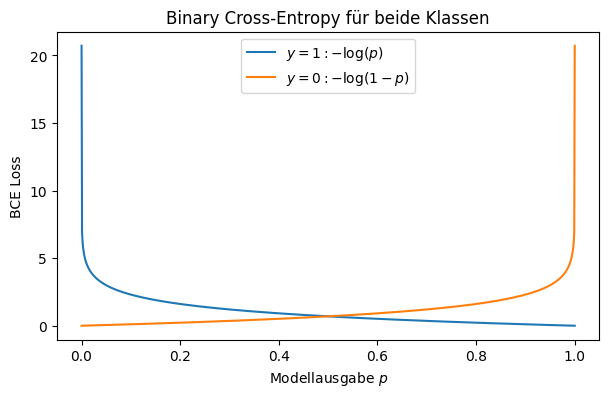

In [10]:
stability_term = 1e-9
p_values = np.linspace(stability_term, 1 - stability_term, 1000)

bce_y1 = -np.log(p_values)
bce_y0 = -np.log(1 - p_values)

fig4, ax4 = plt.subplots(figsize=(7, 4))

ax4.plot(p_values, bce_y1, label=r"$y=1: -\log(p)$")
ax4.plot(p_values, bce_y0, label=r"$y=0: -\log(1-p)$")

ax4.set_xlabel(r"Modellausgabe $p$")
ax4.set_ylabel("BCE Loss")
ax4.set_title("Binary Cross-Entropy für beide Klassen")
ax4.legend()

# Wahrscheinlichkeit des beobachteten Labels und Rolle des Logarithmus

Die Binary Cross-Entropy lässt sich besonders gut verstehen, wenn man nicht nur die vorhergesagte Wahrscheinlichkeit für Klasse $1$ betrachtet, sondern die Wahrscheinlichkeit des tatsächlich beobachteten Labels.

Die Sigmoid-Ausgabe $p_i$ beschreibt zunächst

$$
p_i = P(Y=1 \mid X=x_i)
$$

Für die Bewertung eines konkreten Datenpunkts ist jedoch entscheidend, welches Label tatsächlich beobachtet wurde. Wenn $y_i=1$ gilt, ist die relevante Wahrscheinlichkeit $p_i$. Wenn $y_i=0$ gilt, ist die relevante Wahrscheinlichkeit $1-p_i$.

Diese Fallunterscheidung kann kompakt zusammengefasst werden als

$$
q_i = y_i p_i + (1-y_i)(1-p_i)
$$

Dabei bezeichnet $q_i$ die Wahrscheinlichkeit, die das Modell dem tatsächlich beobachteten Label zuweist. Da $y_i$ nur die Werte $0$ oder $1$ annehmen kann, wirkt $y_i$ in dieser Formel wie ein Schalter:

- Für $y_i=1$ wird $q_i=p_i$.
- Für $y_i=0$ wird $q_i=1-p_i$.

Damit kann die Binary Cross-Entropy für einen einzelnen Datenpunkt auch geschrieben werden als

$$
\mathrm{BCE}(y_i,p_i)=-\log(q_i)
$$

Diese Schreibweise macht die Bedeutung des Losses besonders deutlich: Die BCE ist klein, wenn das Modell dem beobachteten Label eine hohe Wahrscheinlichkeit zuweist, und groß, wenn diese Wahrscheinlichkeit klein ist.

Der negative Logarithmus verstärkt diesen Effekt. Wenn $q_i$ nahe bei $1$ liegt, dann gilt näherungsweise

$$
-\log(q_i) \approx 0
$$

Das Modell hat dem beobachteten Label dann eine hohe Wahrscheinlichkeit gegeben, und der Loss ist entsprechend klein.

Wenn $q_i$ dagegen nahe bei $0$ liegt, dann wird

$$
-\log(q_i)
$$

sehr groß. Das Modell hat dem tatsächlich beobachteten Label dann nur eine sehr geringe Wahrscheinlichkeit zugewiesen.

Die Binary Cross-Entropy bestraft daher besonders stark solche Vorhersagen, bei denen das Modell dem beobachteten Label sehr wenig Wahrscheinlichkeit gibt. Genau dadurch eignet sie sich als Optimierungsziel für probabilistische Klassifikation.


In [11]:
examples = pd.DataFrame({
    "y": [1, 1, 1, 0, 0, 0, 1],
    "p": [0.99, 0.50, 0.01, 0.01, 0.50, 0.99, 0.001]
})

examples["q_observed"] = (
    examples["y"] * examples["p"] 
    + (1 - examples["y"]) * (1 - examples["p"])
)

examples["BCE"] = -np.log(examples["q_observed"])

examples.round(4)

,y,p,q_observed,BCE
0,1,0.990,0.990,0.0101
1,1,0.500,0.500,0.6931
2,1,0.010,0.010,4.6052
3,0,0.010,0.990,0.0101
4,0,0.500,0.500,0.6931
5,0,0.990,0.010,4.6052
6,1,0.001,0.001,6.9078


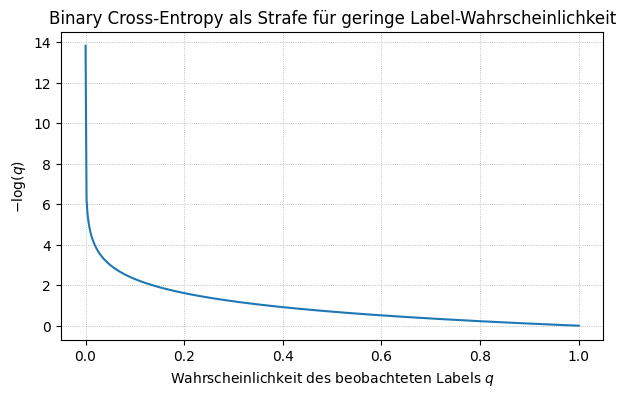

In [12]:

q_values = np.linspace(1e-6, 1, 500)
loss_values = -np.log(q_values)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(q_values, loss_values)

ax.set_xlabel(r"Wahrscheinlichkeit des beobachteten Labels $q$")
ax.set_ylabel(r"$-\log(q)$")
ax.set_title("Binary Cross-Entropy als Strafe für geringe Label-Wahrscheinlichkeit")
ax.grid(ls=":", linewidth=0.6)

plt.show()

## Binary Cross-Entropy über den gesamten Datensatz

Für einen Datensatz mit \(n\) Beobachtungen wird die Binary Cross-Entropy typischerweise als Mittelwert über alle einzelnen Loss-Werte berechnet:

$$
\mathrm{BCE}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Der Mittelwert sorgt dafür, dass der Loss nicht direkt mit der Anzahl der Datenpunkte wächst.

Inhaltlich bedeutet die mittlere Binary Cross-Entropy: Das Modell wird danach bewertet, wie viel Wahrscheinlichkeit es den beobachteten Labels im Durchschnitt zuweist.

In [13]:
def binary_cross_entropy(y_true: np.ndarray, p_pred: np.ndarray) -> float:
    """
    Computes the mean Binary Cross-Entropy.

    Parameters
    ----------
    y_true : np.ndarray
        Binary labels with values 0 or 1.
    p_pred : np.ndarray
        Predicted probabilities for class 1.

    Returns
    -------
    float
        Mean Binary Cross-Entropy.
    """
    y_true = y_true.flatten()
    p_pred = p_pred.flatten()
    stability_term = 1e-9

    p_pred = np.clip(p_pred, stability_term, 1 - stability_term)

    loss = -(
        y_true * np.log(p_pred)
        + (1 - y_true) * np.log(1 - p_pred)
    )

    return np.mean(loss)

## BCE als Funktion der Modellparameter

Bisher wurde die Binary Cross-Entropy als Funktion des beobachteten Labels $y_i$ und der vorhergesagten Wahrscheinlichkeit $p_i$ betrachtet.

Im logistischen Perzeptron entsteht diese Wahrscheinlichkeit jedoch durch die Modellparameter $w$ und $b$:

$$
p_i = \sigma(w^\top x_i + b)
$$

Damit hängt der Loss nicht nur von $p_i$, sondern indirekt von den Parametern des Modells ab. Setzt man die Modellgleichung in die Binary Cross-Entropy ein, erhält man für einen Datenpunkt:

$$
\mathrm{BCE}(y_i,w,b)
=
-\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

Für den gesamten Datensatz wird der Mittelwert über alle Datenpunkte gebildet:

$$
\mathrm{BCE}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

Damit ist das Training des logistischen Perzeptrons als Optimierungsproblem formuliert:

$$
\min_{w,b} \ \mathrm{BCE}(w,b)
$$

Das Ziel besteht also darin, die Gewichte $w$ und den Bias $b$ so zu verändern, dass die mittlere Binary Cross-Entropy auf dem Datensatz möglichst klein wird.

Damit unterscheidet sich das logistische Perzeptron grundlegend von einem rein regelbasierten Update: Wir definieren nun explizit eine Loss-Funktion und suchen Parameter, die diese Loss-Funktion minimieren. Interessierte Leser können dazu in der **Kapitelreihe** Gradient Descent mehr dazu erfahren.

## 8. Gradient for Logistic Perceptron

Selbes Spiel wie bei der **Kapitelreihe** Gradient Descent, nur diesmal mit BCE und zusätzlicher Aktivierung.
Dabei bezeichnet $p_i$ die vorhergesagte Wahrscheinlichkeit für Klasse $1$.
Der rote Term $p_i-y_i$ ist das Fehlersignal am Output.
Er entsteht durch die Kombination aus BCE-Ableitung und Sigmoid-Ableitung.


$$
\Large
\begin{aligned}
\nabla_{w,b}\,\mathrm{BCE}
&=
\begin{bmatrix}
\dfrac{\partial\,\mathrm{BCE}}{\partial w} \\
\dfrac{\partial\,\mathrm{BCE}}{\partial b}
\end{bmatrix}
=
\frac{1}{n}
\sum_{i=1}^{n}
\begin{bmatrix}
x_i{\color{red}{(p_i-y_i)}} \\
{\color{red}{(p_i-y_i)}}
\end{bmatrix}
\\[1em]
\frac{\partial \mathrm{BCE}}{\partial w}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
x_i{\color{red}{(p_i-y_i)}}
\\[0.8em]
\frac{\partial \mathrm{BCE}}{\partial b}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial b}
=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{(p_i-y_i)}}
\end{aligned}
$$

## Warum gerade Sigmoid mit BCE?

Grundsätzlich könnte jede differenzierbare Aktivierungsfunktion mit Wertebereich $(0,1)$ verwendet werden, um einen Wert als Bernoulli-Parameter zu interpretieren. Man könnte also formal schreiben:

$$
p_i = g(z_i)
$$

und diesen Wert als geschätzte Wahrscheinlichkeit für Klasse $1$ verwenden.

Die Sigmoid-Funktion ist jedoch besonders passend, weil sie mit der Binary Cross-Entropy eine sehr einfache und gut interpretierbare Ableitung erzeugt. Für eine allgemeine Aktivierung $g$ gilt mit $p_i=g(z_i)$:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}
=
\frac{p_i-y_i}{p_i(1-p_i)}
\cdot
g'(z_i)
$$

Bei der Sigmoid-Funktion gilt:

$$
g'(z_i)=\sigma(z_i)(1-\sigma(z_i))=p_i(1-p_i)
$$

Dadurch vereinfacht sich das Fehlersignal zu

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}=p_i-y_i
$$

Diese Vereinfachung ist nicht nur rechnerisch elegant, sondern auch semantisch stark: Das Lernsignal ist direkt die Differenz zwischen der vorhergesagten Wahrscheinlichkeit und dem beobachteten Label.

Die Sigmoid-Funktion ist daher nicht nur eine beliebige Transformation in das Intervall $(0,1)$, sondern passt besonders gut zur Bernoulli-Modellannahme und zur Binary Cross-Entropy.

# Visualisierung der Ableitung der BCE und des Fehlersignals

Um das Zusammenspiel aus Binary Cross-Entropy und Sigmoid-Aktivierung besser zu verstehen, visualisieren wir nun sowohl die Ableitung der BCE nach der vorhergesagten Wahrscheinlichkeit $p_i$ als auch das daraus entstehende Fehlersignal. 
Für die Visualisierung ergeben sich zwei Fälle: 
- $y_i=0$ gilt $p_i-y_i=p_i$
- $y_i=1$ gilt $p_i-y_i=p_i-1$. 

Im linken Plot sieht man die Ableitung der Binary Cross-Entropy nach der vorhergesagten Wahrscheinlichkeit $p_i$.

Im rechten Plot sieht man das resultierende Fehlersignal

$$
p_i-y_i
$$

das nach Berücksichtigung der Sigmoid-Ableitung entsteht. Dieses Signal ist deutlich einfacher zu interpretieren:

- Für $y_i=1$ ist das Fehlersignal negativ, solange $p_i<1$.
- Für $y_i=0$ ist das Fehlersignal positiv, solange $p_i>0$.
- Je näher die vorhergesagte Wahrscheinlichkeit am beobachteten Label liegt, desto kleiner ist der Betrag des Fehlersignals.

Genau dieses einfache Fehlersignal verwenden wir im nächsten Schritt, um die Gradienten bezüglich der Modellparameter $w$ und $b$ zu berechnen.

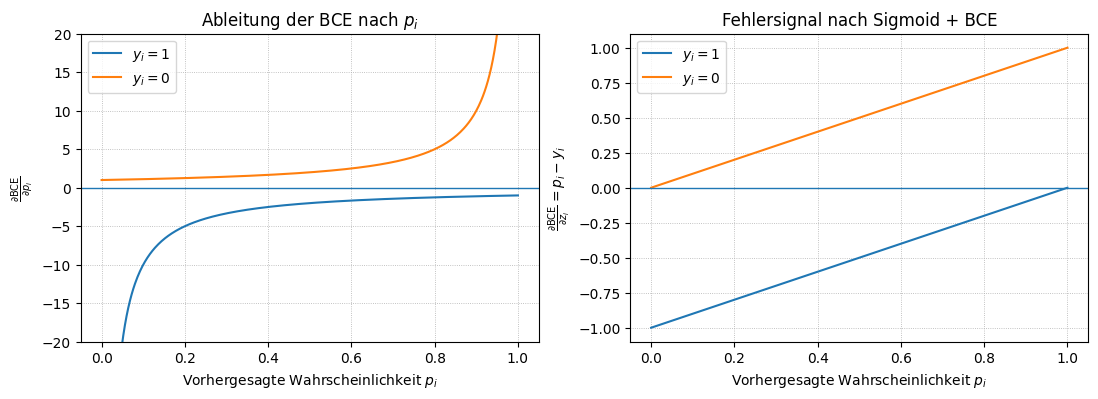

In [14]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-6
p_values = np.linspace(eps, 1 - eps, 500)

# Ableitung der BCE nach p
d_bce_dp_y1 = -1 / p_values
d_bce_dp_y0 = 1 / (1 - p_values)

# Fehlersignal nach Berücksichtigung der Sigmoid-Ableitung:
# dBCE/dz = p - y
signal_y1 = p_values - 1
signal_y0 = p_values - 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linker Plot: Ableitung der BCE nach p
axes[0].plot(p_values, d_bce_dp_y1, label=r"$y_i=1$")
axes[0].plot(p_values, d_bce_dp_y0, label=r"$y_i=0$")
axes[0].axhline(0, linewidth=1)
axes[0].set_xlabel(r"Vorhergesagte Wahrscheinlichkeit $p_i$")
axes[0].set_ylabel(r"$\frac{\partial \mathrm{BCE}}{\partial p_i}$")
axes[0].set_title("Ableitung der BCE nach $p_i$")
axes[0].set_ylim(-20, 20)
axes[0].legend()
axes[0].grid(ls=":", linewidth=0.6)

# Rechter Plot: Fehlersignal p - y
axes[1].plot(p_values, signal_y1, label=r"$y_i=1$")
axes[1].plot(p_values, signal_y0, label=r"$y_i=0$")
axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel(r"Vorhergesagte Wahrscheinlichkeit $p_i$")
axes[1].set_ylabel(r"$\frac{\partial \mathrm{BCE}}{\partial z_i}=p_i-y_i$")
axes[1].set_title("Fehlersignal nach Sigmoid + BCE")
axes[1].legend()
axes[1].grid(ls=":", linewidth=0.6)

## Interpretation der Visualisierung
Durch scharfes sehen können wir nun folgende Schlussfolgerungen treffen:
Die BCE selbst kann sehr große Werte annehmen, wenn das Modell dem beobachteten Label eine sehr kleine Wahrscheinlichkeit zuweist. Auch die Ableitung der BCE nach der Wahrscheinlichkeit $p_i$ kann in diesen Bereichen sehr groß werden.


Im logistischen Perzeptron wird $p_i$ jedoch durch die Sigmoid-Funktion erzeugt:

$$
p_i=\sigma(z_i)
$$

Betrachtet man daher das Fehlersignal am linearen Score $z_i$, ergibt sich durch die Kettenregel:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}
=
\frac{\partial \mathrm{BCE}}{\partial p_i}
\cdot
\frac{\partial p_i}{\partial z_i}
=
p_i-y_i
$$

Damit ist nicht der BCE-Loss selbst beschränkt, sondern das lokale Fehlersignal am Output-Logit. Genau dieses beschränkte und gut interpretierbare Fehlersignal entsteht durch das Zusammenspiel von Sigmoid-Aktivierung und Binary Cross-Entropy.

## Training
Nun können wir die Funktion für das Training erstellen. Als Optimierungsalgorihmus verwenden wir im Moment noch den uns bekannten Full Batch Gradient Descent aus dem Kapitel **Gradient Descent**.





In [15]:
print(f"Shape X : {X.shape}, Shape y: {y.shape}")
def train(model: perceptron.Perceptron, X: np.ndarray, y: np.ndarray, lr=0.001, epochs=20000):
    """
    Trains the logistic Perceptron using full batch gd for BCE+Sigmoid

    Args:
        model Perzeptron object
        X (np.ndarray): Input data of shape (n_samples, n_features).
        y (np.ndarray): Target labels of shape (n_samples, 1) 
        lr (float): Learning rate
        epochs (int): Maximum number of training epochs.

    Returns: 
        list[float]: Mean Binary Cross-Entropy after each epoch. Initial loss is not included.
    """
    y = y.reshape(-1,1)
    loss_history = []
    for epoch in range(epochs):
        prediction = model.forward(X)
        assert prediction.shape == y.shape, "shape missmatch"
        error_signal = (prediction - y)
        model.weight = model.weight - lr * ((X.T @ error_signal)/X.shape[0])
        model.bias = model.bias - lr * np.mean(error_signal)
        prediction = model.forward(X)
        mean_loss = binary_cross_entropy(y, prediction)
        loss_history.append(mean_loss)
    return loss_history

Shape X : (90, 2), Shape y: (90,)


Hier wird das Modell wie gewohnt initialisiert, trainiert und der BCE Loss visualisiert.

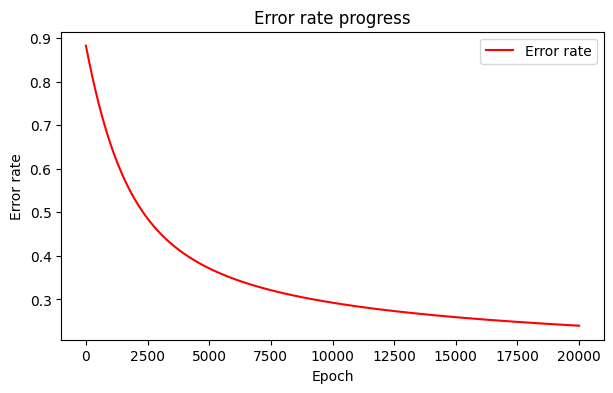

In [16]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
loss_history = train(model, X, y)
fig2, ax2 = perceptron.visualize_training(loss_history)

## Likelihood der beobachteten Daten

Nachdem das logistische Perzeptron für jedes Sample \(x_i\) eine individuelle Wahrscheinlichkeit

$$
p_i = P(Y=1 \mid X=x_i)
$$

liefert, stellt sich die nächste zentrale Frage: **Wie gut passen diese modellierten Wahrscheinlichkeiten zu den tatsächlich beobachteten Zielwerten \(y_i\)?**

Genau diese Frage führt zur **Likelihood**.

### Grundidee der Likelihood

In der Statistik betrachtet man bei der Likelihood die beobachteten Daten als fest und fragt, wie plausibel diese Daten unter einer bestimmten Wahl der Modellparameter sind. Im vorliegenden Fall sind die Modellparameter die Gewichte \(w\) und der Bias \(b\), da sie die Wahrscheinlichkeiten \(p_i = \sigma(w^\top x_i + b)\) bestimmen.

Die Likelihood beantwortet also die Frage:

> Wie wahrscheinlich sind die beobachteten Labels \(y_i\), wenn das Modell gerade die Parameter \(w\) und \(b\) verwendet?

### Likelihood eines einzelnen Datenpunkts

Für einen einzelnen Datenpunkt \(x_i\) mit binärem Zielwert \(y_i \in \{0,1\}\) gilt unter der Bernoulli-Annahme:

- Falls \(y_i = 1\), dann ist die Wahrscheinlichkeit des beobachteten Ergebnisses gleich \(p_i\)
- Falls \(y_i = 0\), dann ist die Wahrscheinlichkeit des beobachteten Ergebnisses gleich \(1-p_i\)

Beides lässt sich kompakt in einer einzigen Formel zusammenfassen:

$$
P(Y_i = y_i \mid X=x_i) = p_i^{y_i}(1-p_i)^{1-y_i}
$$

Diese Schreibweise funktioniert deshalb so elegant, weil:

- für \(y_i=1\) gilt:
  $$
  p_i^1(1-p_i)^0 = p_i
  $$
- für \(y_i=0\) gilt:
  $$
  p_i^0(1-p_i)^1 = 1-p_i
  $$

Damit beschreibt der Ausdruck genau die Wahrscheinlichkeit des **tatsächlich beobachteten** Zielwerts.

### Likelihood des gesamten Datensatzes

Da im Modell angenommen wird, dass die einzelnen Beobachtungen unabhängig voneinander sind, erhält man die Likelihood des gesamten Datensatzes als Produkt der Einzelwahrscheinlichkeiten:

$$
L(w,b)=\prod_{i=1}^{n} p_i^{y_i}(1-p_i)^{1-y_i}
$$

mit

$$
p_i = \sigma(w^\top x_i + b)
$$

Die Likelihood ist also keine neue Verteilung, sondern ein Maß dafür, wie gut eine bestimmte Wahl der Modellparameter die beobachteten Daten erklärt.

### Interpretation

Die Likelihood ist groß, wenn das Modell den tatsächlich beobachteten Labels hohe Wahrscheinlichkeiten zuweist:

- Ein Datenpunkt mit \(y_i=1\) sollte ein großes \(p_i\) erhalten.
- Ein Datenpunkt mit \(y_i=0\) sollte ein kleines \(p_i\) erhalten.

Wenn das Modell dagegen für beobachtete positive Labels sehr kleine Wahrscheinlichkeiten oder für beobachtete negative Labels sehr große Wahrscheinlichkeiten vorhersagt, dann wird die Likelihood klein.

Die Grundidee des Lernens lautet damit:

> Gesucht werden diejenigen Parameter \(w\) und \(b\), unter denen die beobachteten Daten möglichst plausibel sind.

Genau dies entspricht der **Maximierung der Likelihood**.

### Warum dieser Schritt wichtig ist

Mit der Likelihood wird die Modellausgabe nun nicht mehr nur qualitativ als „größer“ oder „kleiner“ interpretiert, sondern quantitativ danach bewertet, wie gut sie die beobachteten Daten erklärt. Damit wird aus dem kontinuierlichen Modelloutput ein echtes statistisches Lernziel.

Im nächsten Schritt wird gezeigt, warum man statt der Likelihood meist mit der **Log-Likelihood** arbeitet und wie daraus schließlich die bekannte **Binary Cross-Entropy** entsteht.

In [17]:


# Beispielhafte Parameter
w = np.array([1.2, -0.8])
b = 0.3

# Modellierte Wahrscheinlichkeiten
z = X @ w + b
p = sigmoid(z)

# Wahrscheinlichkeit des tatsächlich beobachteten Labels
likelihood_i = p**y * (1 - p)**(1 - y)

df_likelihood = pd.DataFrame({
    "y_i": y,
    "z_i": z,
    "p_i = P(Y=1|x_i)": p,
    "P(beobachtetes y_i | x_i)": likelihood_i
})

df_likelihood.round(4)

NameError: name 'sigmoid' is not defined

Die Tabelle zeigt den entscheidenden Unterschied zwischen der modellierten Wahrscheinlichkeit \(p_i\) und der Wahrscheinlichkeit des **tatsächlich beobachteten Labels**.

- \(p_i\) ist die vom Modell geschätzte Wahrscheinlichkeit für Klasse \(1\)
- \(1-p_i\) ist entsprechend die geschätzte Wahrscheinlichkeit für Klasse \(0\)

Welche dieser beiden Größen für einen bestimmten Datenpunkt relevant ist, hängt davon ab, welches Label tatsächlich beobachtet wurde. Genau deshalb wird die Wahrscheinlichkeit des beobachteten Labels mit

$$
p_i^{y_i}(1-p_i)^{1-y_i}
$$

berechnet.

Damit wird die Modellausgabe nicht mehr nur als kontinuierlicher Score betrachtet, sondern direkt danach bewertet, wie plausibel der beobachtete Zielwert unter dieser Vorhersage ist.

In [ ]:
df_cases = pd.DataFrame({
    "y_i": y,
    "p_i": p,
    "1 - p_i": 1 - p,
    "Wahrscheinlichkeit des beobachteten Labels": likelihood_i
})

df_cases.round(4)

,y_i,p_i,1 - p_i,Wahrscheinlichkeit des beobachteten Labels
0,1,0.6628,0.3372,0.6628
1,0,0.2288,0.7712,0.7712
2,1,0.9114,0.0886,0.9114
3,0,0.4514,0.5486,0.5486
4,1,0.7597,0.2403,0.7597
5,0,0.2591,0.7409,0.7409
6,1,0.8261,0.1739,0.8261
7,0,0.1991,0.8009,0.8009
8,0,0.4866,0.5134,0.5134
9,1,0.5469,0.4531,0.5469


In [ ]:
L = np.prod(likelihood_i)

print(f"Likelihood des gesamten Datensatzes: {L:.10f}")

Likelihood des gesamten Datensatzes: 0.0004548521


Die Likelihood des gesamten Datensatzes ergibt sich als Produkt der Einzelwahrscheinlichkeiten. Dadurch wird sofort sichtbar, warum die Likelihood in der Praxis oft sehr klein wird: Es werden viele Zahlen im Intervall \((0,1)\) miteinander multipliziert.

Inhaltlich ist die Bedeutung jedoch klar: Die Likelihood ist genau dann groß, wenn das Modell den beobachteten Zielwerten systematisch hohe Wahrscheinlichkeiten zuweist.

Dann sagt man:

Modell A erklärt die beobachteten Daten besser als Modell B.

Das ist die eigentliche Rolle der Likelihood.

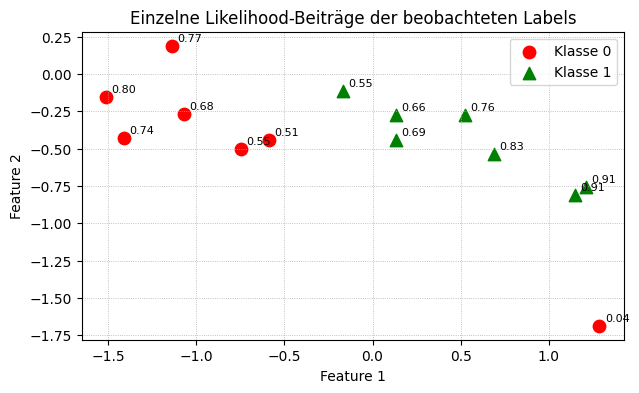

In [ ]:

fig, ax = plt.subplots(figsize=(7, 4))

scatter0 = ax.scatter(X[y == 0, 0], X[y == 0, 1], color="red", marker="o", s=80, label="Klasse 0")
scatter1 = ax.scatter(X[y == 1, 0], X[y == 1, 1], color="green", marker="^", s=80, label="Klasse 1")

for i, (x1, x2) in enumerate(X):
    ax.text(x1 + 0.03, x2 + 0.03, f"{likelihood_i[i]:.2f}", fontsize=8)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Einzelne Likelihood-Beiträge der beobachteten Labels")
ax.legend()
ax.grid(ls=":", linewidth=0.6)

plt.show()

Die eingeblendeten Werte geben für jeden Datenpunkt an, wie wahrscheinlich das **tatsächlich beobachtete Label** unter dem aktuellen Modell ist.

Hohe Werte bedeuten:
- Das Modell erklärt diesen Datenpunkt gut.
- Dem beobachteten Label wurde eine hohe Wahrscheinlichkeit zugewiesen.

Niedrige Werte bedeuten:
- Das Modell erklärt diesen Datenpunkt schlecht.
- Das beobachtete Label wurde unter dem Modell als eher unwahrscheinlich eingestuft.

Damit wird Likelihood auch geometrisch interpretierbar: Ein Modell ist gut, wenn es den beobachteten Datenpunkten die „richtigen“ Wahrscheinlichkeiten zuordnet.

In [ ]:
examples = pd.DataFrame({
    "y_i": [1, 1, 0, 0],
    "p_i": [0.9, 0.55, 0.2, 0.8]
})

examples["P(beobachtetes y_i | x_i)"] = examples["p_i"]**examples["y_i"] * (1 - examples["p_i"])**(1 - examples["y_i"])
examples

,y_i,p_i,P(beobachtetes y_i | x_i)
0,1,0.90,0.90
1,1,0.55,0.55
2,0,0.20,0.80
3,0,0.80,0.20


Das Mini-Beispiel zeigt die Formel noch einmal unabhängig vom Datensatz:

- Wenn \(y_i=1\), dann ist der relevante Wert einfach \(p_i\)
- Wenn \(y_i=0\), dann ist der relevante Wert \(1-p_i\)

Die Likelihood pro Datenpunkt misst also immer, wie gut das Modell genau das erklärt, was tatsächlich beobachtet wurde.

Ein praktisches Problem der Likelihood ist jedoch, dass das Produkt vieler kleiner Wahrscheinlichkeiten sehr schnell extrem kleine Werte liefert. Das erschwert sowohl die Interpretation als auch die numerische Behandlung.

Aus diesem Grund arbeitet man in der Praxis meist nicht direkt mit der Likelihood, sondern mit ihrem Logarithmus. Im nächsten Abschnitt wird daher die **Log-Likelihood** eingeführt.